## Importación de librerías

In [ ]:
# Manipulación de datos
# -----------------------------------------------------------------------
import numpy as np
import pandas as pd
import math

#Exploración de archivos
# -----------------------------------------------------------------------
import sys
sys.path.append('../')

# Estadística y normalización
# -----------------------------------------------------------------------
from scipy.stats import zscore
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, LabelEncoder
from category_encoders import TargetEncoder

# Visualización
# -----------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

## Carga de datos

In [5]:
df = pd.read_csv('../data/dataset_estudiantes_EDA.csv', index_col=0)

df.head()

,horas_estudio_semanal,nota_anterior,tasa_asistencia,horas_sueno,edad,nivel_dificultad,tiene_tutor,horario_estudio_preferido,estilo_aprendizaje,nota_final,aprobado
0,8.957476,48.830601,86.640182,6.675694,25,Fácil,Sí,Tarde,Lectura/Escritura,84.4,1
1,11.042524,80.825707,83.449655,4.616844,18,Difícil,No,Tarde,NaN,72.0,1
2,4.510776,90.383694,74.623607,7.755246,25,Fácil,No,Mañana,Lectura/Escritura,80.0,1
3,6.647213,81.878257,82.849841,8.592826,23,Fácil,No,NaN,Visual,78.2,1
4,1.000000,66.254179,54.539935,6.671840,21,Medio,No,NaN,Auditivo,66.0,1


## Gestión de nulos

In [6]:
# Se identifican de valores nulos en el DataFrame
cantidad_nulos = df.isna().sum()  # Suma valores nulos por columna
cantidad_nulos = cantidad_nulos[cantidad_nulos != 0]  # Filtra solo columnas con valores nulos

cantidad_nulos  # Se muestra el resultado

horas_sueno                  150
horario_estudio_preferido    100
estilo_aprendizaje            50
dtype: int64

In [7]:
# Se analizan de valores únicos en columnas categóricas con valores nulos
for col in cantidad_nulos.index.to_list():
    if col in df.select_dtypes(include='object'):
        display(df[col].value_counts())

horario_estudio_preferido
Noche     344
Tarde     337
Mañana    219
Name: count, dtype: int64

estilo_aprendizaje
Visual               363
Auditivo             254
Kinestésico          178
Lectura/Escritura    155
Name: count, dtype: int64

### Gestión de nulos

Para las columnas categóricas: 'horario_estudio_preferido' y 'estilo_aprendizaje', se utiliza el valor genérico "Unknown" para reemplazar los valores nulos.

Para la columna numérica 'horas_sueno' se reemplazan los nulos por la mediana.

Esta estrategia de imputación preserva la integridad del conjunto de datos mientras proporciona un tratamiento apropiado según el tipo de variable, evitando la eliminación de filas con información parcialmente completa.

In [8]:
# Valor desconocido
val = 'Unknown'

# Columnas categóricas
cols_cat = ['horario_estudio_preferido', 'estilo_aprendizaje']

# Reemplazo de nulos categóricos por 'Unknown'
df[cols_cat] = df[cols_cat].fillna(val)

# Reemplazo de nulos numéricos por la mediana
df['horas_sueno'] = df['horas_sueno'].fillna(df['horas_sueno'].median())

In [9]:
# Se comprueban nulos
df.isna().sum().sum()

np.int64(0)

## Gestión outliers

### Identificación de outliers mediante boxplot

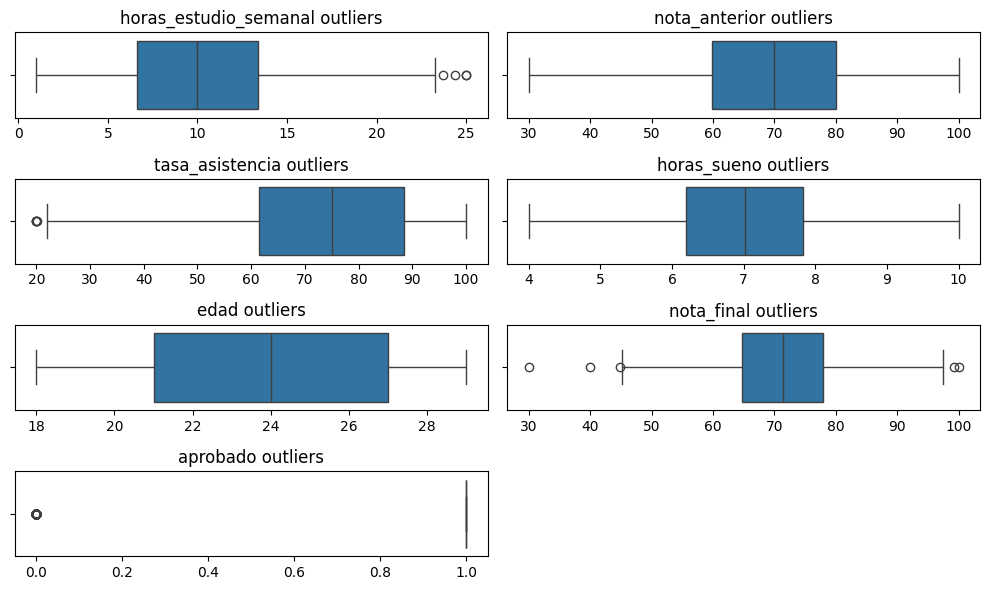

In [10]:
# Visualización de outliers en variables numéricas mediante diagramas de caja

# Se seleccionan solo columnas numéricas del DataFrame
df_num = df.select_dtypes(include=np.number)
cols_num = df_num.columns

# Se calcula el número de gráficos y filas necesarias
n_plots = len(cols_num)
num_rows = math.ceil(n_plots / 2)  # Se distribuyen en 2 columnas

# Se ajusta dinámicamente el tamaño de la figura
width = 5 * 2
height = 1.5 * num_rows
size = (width, height)

# Se crea la estructura de subplots
fig, axes = plt.subplots(nrows=num_rows, ncols=2, figsize=size)
axes = axes.flat  # Convertir matriz de ejes a lista plana

# Se crea un boxplot para cada variable numérica
for i, col in enumerate(cols_num):
   sns.boxplot(
       x=col,
       data=df_num,
       ax=axes[i]
   )

   axes[i].set_title(f'{col} outliers')
   axes[i].set_xlabel('')  # Se elimina etiqueta del eje x para mayor claridad

# Se elimina el último gráfico si sobra un espacio vacío
if n_plots % 2 != 0:
   fig.delaxes(axes[-1])

# Se ajusta el layout y mostrar la figura
plt.tight_layout()
plt.show()


No hay una gran cantidad de outliers en ninguna columna.

## Preproceso para regresión

La variable objetivo es 'nota_final'

In [11]:
# Copia del dataFrame
df_reg = df.copy()

# Variable objetivo
tv = 'nota_final'

### OneHot-encoding

Se aplica OneHotEncoding a 'tiene_tutor' ya que solo tiene dos categorías.

In [12]:
# OneHot-encoding
onehot_encoder = OneHotEncoder(drop=None, sparse_output=False, handle_unknown='ignore')
onehot_encoded = onehot_encoder.fit_transform(df_reg[['tiene_tutor']])
onehot_feature_names = onehot_encoder.get_feature_names_out(['tiene_tutor'])
df_onehot = pd.DataFrame(onehot_encoded, columns=onehot_feature_names, index=df_reg.index)

# Se concatena con el dataFrame original y se eliminan las columnas originales
df_reg = pd.concat([df_reg.drop(columns='tiene_tutor'), df_onehot], axis=1)

### Target-encoding

Se aplica target-encoding a 'horario_estudio_preferido' y 'estilo_aprendizaje'.

In [13]:
# Se definen las columnas
target_cols = ['horario_estudio_preferido', 'estilo_aprendizaje']

# Se aplica target-encodinga a las columnas de una en una
target_encoder = TargetEncoder(cols=target_cols)
df_reg[target_cols] = target_encoder.fit_transform(df_reg[target_cols], df_reg[tv])

### Label-encoding

Se cambian las categorías de 'nivel_dificultad' a 1,2,3 para mantener su relación entre ellas.

In [14]:
df_reg['nivel_dificultad'] = df_reg['nivel_dificultad'].replace({
    'Fácil': 1,
    'Medio': 2,
    'Difícil': 3
})

In [15]:
df_reg.head()

,horas_estudio_semanal,nota_anterior,tasa_asistencia,horas_sueno,edad,nivel_dificultad,horario_estudio_preferido,estilo_aprendizaje,nota_final,aprobado,tiene_tutor_No,tiene_tutor_Sí
0,8.957476,48.830601,86.640182,6.675694,25,1,71.710089,72.594837,84.4,1,0.0,1.0
1,11.042524,80.825707,83.449655,4.616844,18,3,71.710089,68.839539,72.0,1,1.0,0.0
2,4.510776,90.383694,74.623607,7.755246,25,1,71.598174,72.594837,80.0,1,1.0,0.0
3,6.647213,81.878257,82.849841,8.592826,23,1,72.370688,70.526997,78.2,1,1.0,0.0
4,1.000000,66.254179,54.539935,6.671840,21,2,72.370688,71.816929,66.0,1,1.0,0.0


## Escalado (MinMaxScaler)

In [16]:
scaler = MinMaxScaler()
df_reg[df_reg.drop(columns=[tv]).columns] = scaler.fit_transform(df_reg.drop(columns=[tv]))

In [17]:
df_reg.head()

,horas_estudio_semanal,nota_anterior,tasa_asistencia,horas_sueno,edad,nivel_dificultad,horario_estudio_preferido,estilo_aprendizaje,nota_final,aprobado,tiene_tutor_No,tiene_tutor_Sí
0,0.331561,0.269009,0.833002,0.445949,0.636364,0.0,0.577230,1.000000,84.4,1.0,0.0,1.0
1,0.418439,0.726082,0.793121,0.102807,0.000000,1.0,0.577230,0.000000,72.0,1.0,1.0,0.0
2,0.146282,0.862624,0.682795,0.625874,0.636364,0.0,0.505606,1.000000,80.0,1.0,1.0,0.0
3,0.235301,0.741118,0.785623,0.765471,0.454545,0.0,1.000000,0.449354,78.2,1.0,1.0,0.0
4,0.000000,0.517917,0.431749,0.445307,0.272727,0.5,1.000000,0.792851,66.0,1.0,1.0,0.0


### Guardado de dataframe preprocesado

In [18]:
df_reg.to_csv('../data/df_regresion.csv')

## Preproceso para clasificación

La variable objetivo es 'aprobado'

In [19]:
# Copia del dataFrame
df_clas = df.copy()

# Variable objetivo
tv = 'aprobado'

### Codificación

In [20]:
cat_cols = df_clas.select_dtypes(include='O').columns.to_list()

Selección de los métodos de codificación.

(Se utilizan los mismos que para regresión cambiando la variable objetivo).

### OneHot-encoding

Se aplica OneHotEncoding a 'tiene_tutor' ya que solo tiene dos categorías.

In [21]:
# OneHot-encoding
onehot_encoder = OneHotEncoder(drop=None, sparse_output=False, handle_unknown='ignore')
onehot_encoded = onehot_encoder.fit_transform(df_clas[['tiene_tutor']])
onehot_feature_names = onehot_encoder.get_feature_names_out(['tiene_tutor'])
df_onehot = pd.DataFrame(onehot_encoded, columns=onehot_feature_names, index=df_clas.index)

# Se concatena con el DataFrame original y se eliminan las columnas originales
df_clas = pd.concat([df_clas.drop(columns='tiene_tutor'), df_onehot], axis=1)

### Target-encoding

Se aplica target-encoding a 'horario_estudio_preferido' y 'estilo_aprendizaje'.

In [22]:
# Se aplica target-encodinga a las columnas de una en una
target_cols = ['horario_estudio_preferido', 'estilo_aprendizaje']

target_encoder = TargetEncoder(cols=target_cols)
df_clas[target_cols] = target_encoder.fit_transform(df_clas[target_cols], df_clas[tv])

### Label-encoding

Se cambian las categorías de 'nivel_dificultad' a 1,2,3 para mantener su relación entre ellas.

In [23]:
df_clas['nivel_dificultad'] = df_clas['nivel_dificultad'].replace({
    'Fácil': 1,
    'Medio': 2,
    'Difícil': 3
})

In [24]:
df_clas.head()

,horas_estudio_semanal,nota_anterior,tasa_asistencia,horas_sueno,edad,nivel_dificultad,horario_estudio_preferido,estilo_aprendizaje,nota_final,aprobado,tiene_tutor_No,tiene_tutor_Sí
0,8.957476,48.830601,86.640182,6.675694,25,1,0.905045,0.941935,84.4,1,0.0,1.0
1,11.042524,80.825707,83.449655,4.616844,18,3,0.905045,0.823699,72.0,1,1.0,0.0
2,4.510776,90.383694,74.623607,7.755246,25,1,0.913242,0.941935,80.0,1,1.0,0.0
3,6.647213,81.878257,82.849841,8.592826,23,1,0.949983,0.878788,78.2,1,1.0,0.0
4,1.000000,66.254179,54.539935,6.671840,21,2,0.949983,0.913386,66.0,1,1.0,0.0


### Escalado (MinMaxScaler)

In [25]:
scaler = MinMaxScaler()
df_clas[df_reg.drop(columns=[tv]).columns] = scaler.fit_transform(df_clas.drop(columns=[tv]))

In [26]:
df_clas.head()

,horas_estudio_semanal,nota_anterior,tasa_asistencia,horas_sueno,edad,nivel_dificultad,horario_estudio_preferido,estilo_aprendizaje,nota_final,aprobado,tiene_tutor_No,tiene_tutor_Sí
0,0.331561,0.269009,0.833002,0.445949,0.636364,0.0,0.463128,1.000000,0.777143,1,0.0,1.0
1,0.418439,0.726082,0.793121,0.102807,0.000000,1.0,0.463128,0.000000,0.600000,1,1.0,0.0
2,0.146282,0.862624,0.682795,0.625874,0.636364,0.0,0.561063,1.000000,0.714286,1,1.0,0.0
3,0.235301,0.741118,0.785623,0.765471,0.454545,0.0,1.000000,0.465920,0.688571,1,1.0,0.0
4,0.000000,0.517917,0.431749,0.445307,0.272727,0.5,1.000000,0.758538,0.514286,1,1.0,0.0


### Guardado de dataframe preprocesado

In [27]:
df_clas.to_csv('../data/df_clasificacion.csv')